## Aprendizaje no supervisado

Recordemos que este es simplemente un repaso de los métodos usados con sickit-learn. No se esta haciendo profundización en los métodos ni nada por el estilo. 

Nota importante de la distinción del aprendizaj supervisado al no supervisado. En el aprendizaj supervisado tenemos una variable objetivo que deseamos CLASIFICAR o predecir con una REGRESIÓN. Con el aprendizaje no supervisado no existe esa variable respuesta la cual me dará un valor o me dirá a donde pertenecen estos datos, el aprendizaje no supervisado encuentra la información instrínseca a los datos, los agrupa, comprime y entiende su naturaleza geométrica. No busca asignar respuestas correctas preexistentes, sino revelar la organización o arquitectura oculta de la información.

In [21]:
import numpy as np

np.random.seed(1)

In [22]:
#
# K-means clustering
#
from sklearn import cluster, datasets # agrupamiento


X_iris, y_iris = datasets.load_iris(return_X_y=True)

# instancia del métood e agrupamiento k-means
# con la cantidad de clusters que se quieren realizar. 
k_means = cluster.KMeans(n_clusters=3)

# hacemos el entrenamiento del modelo, que sería
# explícitamente hacer los cálculos que require y guardar
# los clusters que se obtienen que corresponden a los centros
# de los grupos. 
k_means.fit(X_iris)


# el método labels me dice las etiquetas de los grupos
# que se le da a cada uno de los ejemplos. En este caso
# como se decidieron hacer 3 clusters, entonces las etiquetas
# son los valores 0, 1 y 2. 
display(k_means.labels_[::10])

# estos son los valores reales. 
display(y_iris[::10])

# es importante mencionar que las etiquetas no tiene porque ser iguales
# lo que importa es que los respectivos valores los 
# agrupa de una manera diferente en 3 grupos entre ellos
# como pasa con los datosd reales de Y. 


array([1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2], dtype=int32)

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])

## Vector quantization
Esta es una técnica de compresión que reemplaza un conjunto infinito o enorme de datos coninuos por un grupo pequeño y fijo de
vecotres representativos. 

¿Cómo funciona?

1. Creación del diccionario(codebook): Se analizan los datos originales y se agrupan mediante un algoritmo como k-means. El centroide de cada grupo se convierte en un punto representativo del diccionario. 

2. Asignación (Cuantización): Cada vector original x se compara con el diccionario y se reemplaza por el índice i del centroide más cerano. 

3. Comprensión: En lugar de guardar los vectores complejos originales, solo guardas la lista de índices y la tabla del diccionario. 

Esta es una gran teçnica en bases de datos vectoriale sy búsqueda en IA pues premite comprimir valores y búsquedas ultra rápidas. 



In [23]:
#
# Vector quantization
# 
import scipy as sp

try:
    # importar imagenm de mapache
    face = sp.face(gray=True)
except AttributeError:
    from scipy import misc
    face = misc.face(gray=True)

# Transforma los datos a un array de (n_sample, n_feature)
X = face.reshape((-1, 1)) # esto en específico es para 
# transformar un arreglo unidimensionarl en una matriz 
# bidimensional con N filas y exactamente 1 columna. 
# el -1 representa las filas autmáticas tomadas
# como el número de elementos. Se usa básicamente
# para entregar los datos como un vector columna ya que esta 
# es la forma en que los métodos de sickit-learn reciben
# los datos. 

# creamos una instancia de k-means
k_means = cluster.KMeans(
    n_clusters=5, # 5 clusters
    n_init=1, # número de veces que el algoritmo corre con diferentes semillas para los centros
)

# entrenamiento del modelo.
k_means.fit(X)

# el método
values = k_means.cluster_centers_.squeeze()
labels = k_means.labels_
face_compressed = np.choose(labels, values)
face_compressed.shape = face.shape

AttributeError: module 'scipy.misc' has no attribute 'face'

## Agrupamiento jerárquico: Aglomerativo o divisivo
Es un método de aprendizaje no supervisado que ogarniza los datos en una estructura de forma de árbol llamada dendograma, mostrando cómo se agrupan los puntos a diferentes niveles de similitud. 

Estrategias de construcción: 

* Aglomerativo (Bottom-Up): Es el enfoque más utilizado. Comienza asumiendo que cada dato es su propio grupo. En cada paso, calcula las distancias y une los dos grupos más cercanos hasta que todos los puntos terminan en un único gran grupo.

* Divisivo (Top-Down): Funciona a la inversa. Parte de un solo grupo con todos los datos y lo va dividiendo recursivamente en subgrupos cada vez más pequeños.

Criterios de Enlace (Linkage)

Para decidir qué dos grupos deben unirse, el algoritmo necesita medir la distancia entre conjuntos de puntos. Los métodos más comunes son:

Single (Enlace simple): Mide la distancia entre los dos puntos más cercanos de cada grupo. Puede crear grupos "alargados" (efecto encadenamiento).

Complete (Enlace completo): Mide la distancia entre los dos puntos más lejanos de cada grupo. Tiende a crear grupos compactos y esféricos.

Average (Promedio): Mide la distancia promedio entre todos los pares de puntos de ambos grupos.

Ward: Minimiza la varianza total dentro de los grupos al unirlos. Es el criterio más robusto y utilizado en la práctica.

El Dendrograma y la elección de $K$A diferencia de $K$-Means, el agrupamiento jerárquico no requiere definir el número de grupos ($K$) antes de empezar.El resultado es el dendrograma: un diagrama donde la altura de las ramas representa la distancia a la que se unieron los grupos. Para definir el número final de clusters, simplemente realizas un "corte" horizontal a la altura deseada

Ventajas y Limitaciones

Ventajas: Muestra la jerarquía real de los datos y no requiere fijar $K$ de antemano.

Desventajas: Su complejidad computacional es alta ($\mathcal{O}(N^3)$ en implementaciones simples o $\mathcal{O}(N^2)$ optimizada), por lo que es inviable para conjuntos de datos masivos.

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.data import coins # conjutno de imágenes de mones
#para agrupar con las similares. 

from skimage.transform import rescale

# 1. Cargar imagen base, conjunto de monedas
# y se quiren agrupar las similares
imagen_base = coins()

# 2. Suavizar con filtro Gaussiano (sigma=2)
# Esto lo que hace es un desenfoque suave a una imagen
# recalculando el valo rde cada pixel mediante
# un promedio ponderado de sus vecinos. Elimina el ruido
# visual y suavisar los detalles finos sin alterar drásticamente la estr-
# uctrua general de la imagen. 
# La imagen genera un matriz de pesos, y estos pesos 
# siguen una distribución normal bi-dimensional. esta 
# es la distribución normal bivariada con vector de medias
# siendo (0,0) y siendo 0 la covarianza entre las varaibles. 
# además de igual varianza las varaibles (isotropía). Por lo
# que es el caso de la distrib. normal bivariada
# en su caso isotrópico, no correlacionado y centrado en el 
# origen. 
imagen_suavizada = gaussian_filter(imagen_base, sigma=2)

# 3. Reescalar al 20% con parámetros compatibles para versiones modernas
rescaled_coins = rescale(
    imagen_suavizada,
    scale=0.2,
    mode="reflect",
    anti_aliasing=False,
    channel_axis=None  # Desactiva búsqueda de canales de color en imágenes 2D
)

# 4. Transformar matriz (Alto, Ancho) a vector columna (N, 1)
# para tener un vector columna. 
X = np.reshape(rescaled_coins, (-1, 1))

print("Forma de la imagen reescalada:", rescaled_coins.shape)
print("Forma de la matriz X para ML:", X.shape)

Forma de la imagen reescalada: (61, 77)
Forma de la matriz X para ML: (4697, 1)


In [ ]:
X

array([[0.50959853],
       [0.52156988],
       [0.51372549],
       ...,
       [0.29816654],
       [0.2262007 ],
       [0.0351789 ]], shape=(4697, 1))

In [ ]:
from sklearn.feature_extraction import grid_to_graph
# crear matriz de conectividad dispersa que define 
# que píxeles son vecinos inmediatos dentro de una 
# imagen o rejilla multidimensional 

# construye un grafo de rejilla donde cada píxel represetna un
# nodo  las aristas representan la contigüedad física
# entre píxeles adyacentes. 
connectivity = grid_to_graph(*rescaled_coins.shape)

# rescales_coins es el arreglo multidimensional que representa
# la imagen en al escala de grises. y * es el operador de desemp-
# aquetado de tuplas que pasa como argumentos posicionales
# independientes a la función. 

In [ ]:
rescaled_coins.shape

AttributeError: 'tuple' object has no attribute 'type'

In [ ]:
rescaled_coins.shape

(61, 77)

In [ ]:
n_clusters = 27  # se definen 27 clusters. 

#se importa el algoritmo de agrupamiento aglomerativo
from sklearn.cluster import AgglomerativeClustering

# se definen los parámetros 
ward = AgglomerativeClustering(
    n_clusters=n_clusters, # número de clusters
    linkage="ward", # algoritmos
    connectivity=connectivity,
)

#entrenamiento
ward.fit(X)

# Mostrar el agrupamiento de las imágenes por similaridad
# etiquetas:        etiquetas   ,    dimensiones
label = np.reshape(ward.labels_, rescaled_coins.shape)
# En este caso entonces se reescala el vector columna
# de las etiquetas y re-escribirlo en las dimensiones
# de rescales_coins. 

# mostrar las 10 primeras filas y todas las columnas. 
label[:10]

array([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2],
       [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2],
       [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,
         2,  2

In [ ]:
#
# Feature agglomeration
#
digits = datasets.load_digits()
images = digits.images
X = np.reshape(images, (len(images), -1))
connectivity = grid_to_graph(*images[0].shape)

agglo = cluster.FeatureAgglomeration(
    connectivity=connectivity,
    n_clusters=32,
)
agglo.fit(X)
X_reduced = agglo.transform(X)

X_approx = agglo.inverse_transform(X_reduced)
images_approx = np.reshape(X_approx, images.shape)

## Feature agglomeration
En este caso el clusterring también sirve para tratar el problema de la maldicion de la dimensionalidad. 

In [ ]:
from sklearn import datasets
#
# Feature agglomeration
#
digits = datasets.load_digits()
images = digits.images # arreglo (1797,8,8)
# 1797 cada una es una matriz 8x8, es una tabla
# tridimensional. 

# Dar una estructura bidimensional
# de 1797 imágenes y el -1 es el resto, que sería
# 8x8 = 64, osea, hace la matriz una sola
# fila de 64 columnas
X = np.reshape(images, (len(images), -1))

# Crear matriz de conectividad. 
connectivity = grid_to_graph(*images[0].shape)

# Algoritmo de agrupamiento 
agglo = cluster.FeatureAgglomeration(
    connectivity=connectivity,
    n_clusters=32, # con 32 clusters
)

# entrenamiento
agglo.fit(X)

# obtener el X reducido obteniendo el reducido
X_reduced = agglo.transform(X)

# Se aplica transformación inversa al reducido. 
X_approx = agglo.inverse_transform(X_reduced)

# convertirlo nuevamente en una matriz 
# para cada imagen. 
images_approx = np.reshape(X_approx, images.shape)

In [28]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

# Descompositions
Sickit-learn también tiene en su estructura algoritmos de descompocisición para reducir la cantidad de columnas que tiene
la matriz X, por ejemplo para eliminar las columnas que no aportan variblidad al modelo o que son combinaciones lineales
de las otras. 


In [2]:
import numpy as np


# Crea una señal con dos variables informativas
x1 = np.random.normal(size=(100, 1))
x2 = np.random.normal(size=(100, 1))
x3 = x1 + x2 # combinación lineal de las anteriores
X = np.concatenate([x1, x2, x3], axis=1) # axis = 1
# es para hacer la concatenación por columnas

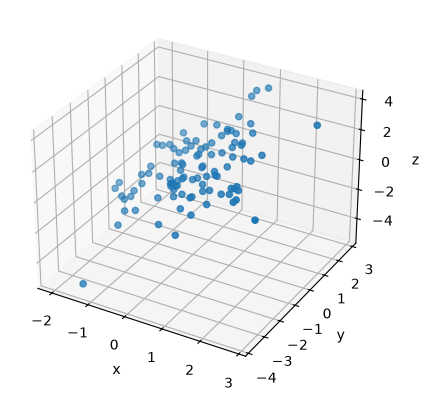

In [3]:
import matplotlib.pyplot as plt

# es claro que tener 3 columnas es una dimensión más
# que no le aporta nada de información a mi problema original

fig = plt.figure() # iniciar contenedor para elgráfico

# nrows = 1, ncols = 1, index = 1 quiere decir
# una cuadrícula de 1x1 y pone el gráfico 
# en la posición 1. Al hace projection = 3d
# habilita el espacio tridimensional en el sistema
# de ejes permitiendo rotación interaciva y manejo
# de profundidad. 
ax = fig.add_subplot(111, projection="3d")

# todas las filas de x1 al eje X
# todas la filas de x2 al eje Y
# todas la filas de x3 al eje z
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
_ = ax.set(xlabel="x", ylabel="y", zlabel="z")

In [ ]:
#
# Principal component analysis (PCA)
#
from sklearn import decomposition

# instancia del análisis de componentes principales
pca = decomposition.PCA()

# entrenamiento dél método
pca.fit(X)

# mostrar las varianzas explicadas
# de mayor a menor por cada 
# componente principal
print(pca.explained_variance_)

s = 0
l = []
for i in range(len(pca.explained_variance_)):
    s += pca.explained_variance_[i]
    l.append(s)

print(l) # varianza acumulada
print(list(map(lambda x: x/l[-1],l))) # porcentaje de variabilidad explicda acumulada

[3.30643802e+00 1.07780406e+00 8.11394307e-16]
[np.float64(3.3064380161383706), np.float64(4.384242078669069), np.float64(4.38424207866907)]
[np.float64(0.754164107913975), np.float64(0.9999999999999998), np.float64(1.0)]


A partir de lo anterior es claro  que solo las primeras 2 variables explican el 0.99999999% de varibilidad de los datos
por tanto sería adecuado solo usar las primeras 2 componentes
principales para usar lo datos y por ende reducir la dimensionalidad
 

In [ ]:
# cambiamos a que el número de componentes sea 2. 
pca.set_params(n_components=2)

# Entrenamos el modelo, es decir, hacer los cáclulos 
# del PCA y retorne directamene los valores de X
# trasnformados en los nuevos ejes. 
X_reduced = pca.fit_transform(X)

# ver la nueva dimensionalidad. 
X_reduced.shape

## Análisisd de componentes independientes. 

In [6]:
#
# Independent Component Analysis: ICA
#
# Generate sample data
import numpy as np
from scipy import signal

# 2000 puntos igualmente espciados ente 0 y 10
time = np.linspace(0, 10, 2000) 

# Onda de seno
s1 = np.sin(2 * time)  # Signal 1 : sinusoidal signal

# Onda de seno
s2 = np.sign(np.sin(3 * time))  # Signal 2 : square signal

# Onda de seno
s3 = signal.sawtooth(2 * np.pi * time)  # Signal 3: saw tooth signal

# concatenación
S = np.c_[s1, s2, s3]

# añadir ruido
S += 0.2 * np.random.normal(size=S.shape)  # Add noise

# estandarizar
S /= S.std(axis=0)  # Standardize data

# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1], [1.5, 1, 2]])  # Mixing matrix
X = np.dot(S, A.T)  # Generate observations

In [ ]:
# Computa ICA
# Este método separa una señal multivariada en subcomponentes aditivas
# maximizando la independencia entre ellas. Usualmente se usa para
# separa señales superpuestas. Si puedo separarlas puedo proyectarlas

# Deifinición de instancia
ica = decomposition.FastICA()

# ajute y transformación de los datos. 
S_ = ica.fit_transform(X)  # Get the estimated sources

# separar señales
A_ = ica.mixing_.T


np.allclose(X, np.dot(S_, A_) + ica.mean_)